<a href="https://colab.research.google.com/github/Viktoria-coder-prog/program-learning/blob/main/%D0%98%D0%90%D0%A0_%D0%B2%D0%B0%D1%80%D0%B8%D0%B0%D0%BD%D1%82_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Вариант+1.+dataset_target_company.csv")

Первичная обработка данных

In [ ]:
# просмотр данных
df.head(2)

,AGREEMENT_RK,TARGET,AGE,SOCSTATUS_WORK_FL,SOCSTATUS_PENS_FL,GENDER,CHILD_TOTAL,DEPENDANTS,EDUCATION,MARITAL_STATUS,...,GAR_PRESENCE_FL,LAND_PRESENCE_FL,CREDIT,TERM,FACT_LIVING_TERM,WORK_TIME,LOAN_NUM_PAYM,LOAN_DLQ_NUM,LOAN_MAX_DLQ_AMT,DATE_CREDIT
0,59910150,0,49,1,0,1,2,1,Среднее специальное,Состою в браке,...,0,0,8000.0,6,220,18.0,6,2,1580.0,2017-10-01 15:09:09
1,59910230,0,32,1,0,1,3,3,Среднее,Состою в браке,...,0,0,21650.0,6,137,97.0,6,1,4020.0,2020-10-09 18:58:35


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15223 entries, 0 to 15222
Data columns (total 37 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   agreement_rk             15223 non-null  int64  
 1   target                   15223 non-null  int64  
 2   age                      15223 non-null  int64  
 3   socstatus_work_fl        15223 non-null  int64  
 4   socstatus_pens_fl        15223 non-null  int64  
 5   gender                   15223 non-null  int64  
 6   child_total              15223 non-null  int64  
 7   dependants               15223 non-null  int64  
 8   education                15223 non-null  object 
 9   marital_status           15223 non-null  object 
 10  gen_industry             13856 non-null  object 
 11  gen_title                13856 non-null  object 
 12  org_tp_state             13856 non-null  object 
 13  org_tp_fcapital          13858 non-null  object 
 14  job_dir               

In [ ]:
# приводим к нижнему регистру
df.columns = df.columns.str.lower()

In [ ]:
# преобразуем текстовую дату кредита
df["date_credit"] = pd.to_datetime(df["date_credit"])

In [ ]:
# проверка дубликатов (явных дубликатов нет)
print("Количество полных дубликатов:", df.duplicated().sum())

Количество полных дубликатов: 0


In [ ]:
# убеждаемся в уникальности ключевого столбца ID договора
df = df.drop_duplicates(subset=["agreement_rk"]).reset_index(drop=True)

In [ ]:
# проверка аномальных значений
# fact_living_term > 1200 мес (100 лет) - заменяем на медиану
df.loc[df["fact_living_term"] > 1200, "fact_living_term"] = df["fact_living_term"].median()

# work_time > 600 мес (50 лет) - явный выброс, заменяем на медиану по рабочим
df.loc[df["work_time"] > 600, "work_time"] = df["work_time"].median()

In [ ]:
# восстановление пропущенных значений
cat_cols_with_na = [
    "gen_industry",
    "gen_title",
    "org_tp_state",
    "org_tp_fcapital",
    "job_dir",
    "tp_province",
    "region_nm",]
for col in cat_cols_with_na:
    df[col] = df[col].fillna("Unknown")

df["work_time"] = df["work_time"].fillna(df["work_time"].median())

In [ ]:
# проверка результатов
print(f"Количество оставшихся пропущенных значений: {df.isna().sum().sum()}")
print(f"Итоговый размер таблицы: {df.shape}")

Количество оставшихся пропущенных значений: 0
Итоговый размер таблицы: (15223, 37)


Добавление признаков

In [ ]:
# день недели, месяц и год взятия кредита
df["credit_dayofweek"] = df["date_credit"].dt.dayofweek
df["credit_day_name"] = df["date_credit"].dt.day_name()
df["credit_month"] = df["date_credit"].dt.month
df["credit_year"] = df["date_credit"].dt.year

In [ ]:
# адрес регистрации и адрес фактического пребывания клиента совпадают (1 -- совпадает, 0 -- не совпадает)
df["reg_fact_equal"] = (
    df["reg_address_province"] == df["fact_address_province"]
).astype(int)

In [ ]:
# адрес фактического пребывания клиента и его почтовый адрес совпадают(1 -- совпадает, 0 -- не совпадает)
df["fact_post_equal"] = (
    df["fact_address_province"] == df["postal_address_province"]
).astype(int)

In [ ]:
# адрес регистрации клиента и его почтовый адрес совпадают(1 -- совпадает, 0 -- не совпадает)
df["reg_post_equal"] = (
    df["reg_address_province"] == df["postal_address_province"]
).astype(int)

In [ ]:
# почтовый, фактический и адрес регистрации совпадают (1 -- совпадают, 0 -- не совпадают)
df["three_equal"] = (
    (df["reg_address_province"] == df["fact_address_province"])
    & (df["fact_address_province"] == df["postal_address_province"])
).astype(int)

In [ ]:
# область регистрации, фактического пребывания, почтового адреса и область расположения торговой точки,
# где клиент брал кредит совпадают (1 -- совпадают, 0 -- не совпадают)
df["all_equal"] = (
    (df["reg_address_province"] == df["fact_address_province"])
    & (df["fact_address_province"] == df["postal_address_province"])
    & (df["postal_address_province"] == df["tp_province"])
).astype(int)

In [ ]:
# проверка
new_columns = [
    "credit_dayofweek",
    "credit_month",
    "credit_year",
    "reg_fact_equal",
    "fact_post_equal",
    "reg_post_equal",
    "three_equal",
    "all_equal",
]

print("Первые 5 строк с новыми признаками")
print(df[new_columns].head())

Первые 5 строк с новыми признаками
   credit_dayofweek  credit_month  credit_year  reg_fact_equal  \
0                 6            10         2017               1   
1                 4            10         2020               1   
2                 1             5         2015               1   
3                 6             6         2016               1   
4                 6             3         2016               1   

   fact_post_equal  reg_post_equal  three_equal  all_equal  
0                1               1            1          1  
1                1               1            1          0  
2                1               1            1          1  
3                1               1            1          1  
4                1               1            1          0  


Исследовательский анализ данных

In [ ]:
# настройки оформления графиков
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.figsize'] = (16, 12)
pd.set_option('display.max_columns', None)

In [ ]:
# добавление целевого признака target (0 - кредит возвращен, 1 - кредит просрочен)
print(df['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

target
0    88.1 %
1    11.9 %
Name: proportion, dtype: object


In [ ]:
# исследование динамики количества кредитов по годам, месяцам
# по годам
yearly_stats = df.groupby('credit_year')['target'].agg(
    Количество_кредитов = 'count',
    Количество_дефолтов = 'sum',
    Доля_дефолтов_проц = lambda x: round(x.mean() * 100, 2)
).reset_index()

print("Динамика по годам")
display(yearly_stats)

# по месяцам
monthly_stats = df.groupby('credit_month')['target'].agg(
    Количество_кредитов = 'count',
    Количество_дефолтов = 'sum',
    Доля_дефолтов_проц = lambda x: round(x.mean() * 100, 2)
).reset_index()

print("Сезонность по месяцам")
display(monthly_stats)

Динамика по годам


,credit_year,Количество_кредитов,Количество_дефолтов,Доля_дефолтов_проц
0,2015,2096,271,12.93
1,2016,2179,256,11.75
2,2017,2280,251,11.01
3,2018,2149,245,11.40
4,2019,2108,244,11.57
5,2020,2191,269,12.28
6,2021,2220,276,12.43


Сезонность по месяцам


,credit_month,Количество_кредитов,Количество_дефолтов,Доля_дефолтов_проц
0,1,1291,141,10.92
1,2,1236,169,13.67
2,3,1271,121,9.52
3,4,1291,150,11.62
4,5,1293,165,12.76
5,6,1287,165,12.82
6,7,1250,159,12.72
7,8,1230,138,11.22
8,9,1261,147,11.66
9,10,1252,164,13.10


In [ ]:
# исследование числовых в разрезе целевого признака (target)
num_features = [
    'age',
    'personal_income',
    'credit',
    'term',
    'dependants',
    'loan_num_paym',
    'loan_dlq_num',
    'loan_max_dlq_amt'
]

mean_df = df.groupby('target')[num_features].mean().T
median_df = df.groupby('target')[num_features].median().T

num_comparison = pd.DataFrame({
    'Выплачен (0) - Mean': mean_df[0],
    'Выплачен (0) - Median': median_df[0],
    'Дефолт (1) - Mean': mean_df[1],
    'Дефолт (1) - Median': median_df[1]
})

display(num_comparison.round(2))

,Выплачен (0) - Mean,Выплачен (0) - Median,Дефолт (1) - Mean,Дефолт (1) - Median
age,40.85,40.0,37.13,36.0
personal_income,13540.44,12000.0,16173.38,15000.0
credit,14498.00,11496.0,15925.89,12175.0
term,8.00,6.0,8.81,9.0
dependants,0.63,0.0,0.76,1.0
loan_num_paym,7.97,5.0,7.20,5.0
loan_dlq_num,0.18,0.0,0.29,0.0
loan_max_dlq_amt,219.97,0.0,413.60,0.0


In [ ]:
# исследование категориальных в разрезе целевого признака (target)
cat_features = [
    'socstatus_work_fl',
    'socstatus_pens_fl',
    'education',
    'marital_status',
    'family_income'
]

for col in cat_features:
    print(f"Признак: {col}")
    summary = df.groupby(col)['target'].agg(
        Всего_клиентов ='count',
        Дефолтов ='sum',
        Доля_дефолтов_проц =lambda x: round(x.mean() * 100, 2)
    ).sort_values(by='Доля_дефолтов_проц', ascending=False)
    display(summary)

Признак: socstatus_work_fl


,Всего_клиентов,Дефолтов,Доля_дефолтов_проц
socstatus_work_fl,,,
1,13847,1759,12.70
0,1376,53,3.85


Признак: socstatus_pens_fl


,Всего_клиентов,Дефолтов,Доля_дефолтов_проц
socstatus_pens_fl,,,
0,13176,1711,12.99
1,2047,101,4.93


Признак: education


,Всего_клиентов,Дефолтов,Доля_дефолтов_проц
education,,,
Два и более высших образования,20,4,20.00
Неоконченное высшее,532,102,19.17
Неполное среднее,340,48,14.12
Среднее специальное,6518,786,12.06
Среднее,4679,537,11.48
Высшее,3133,335,10.69
Ученая степень,1,0,0.00


Признак: marital_status


,Всего_клиентов,Дефолтов,Доля_дефолтов_проц
marital_status,,,
Гражданский брак,352,58,16.48
Разведен(а),1245,181,14.54
Не состоял в браке,3622,462,12.76
Состою в браке,9416,1059,11.25
Вдовец/Вдова,588,52,8.84


Признак: family_income


,Всего_клиентов,Дефолтов,Доля_дефолтов_проц
family_income,,,
свыше 50000 руб.,492,114,23.17
от 20000 до 50000 руб.,6082,797,13.10
от 10000 до 20000 руб.,7077,769,10.87
до 5000 руб.,60,6,10.00
от 5000 до 10000 руб.,1512,126,8.33


Визуализация

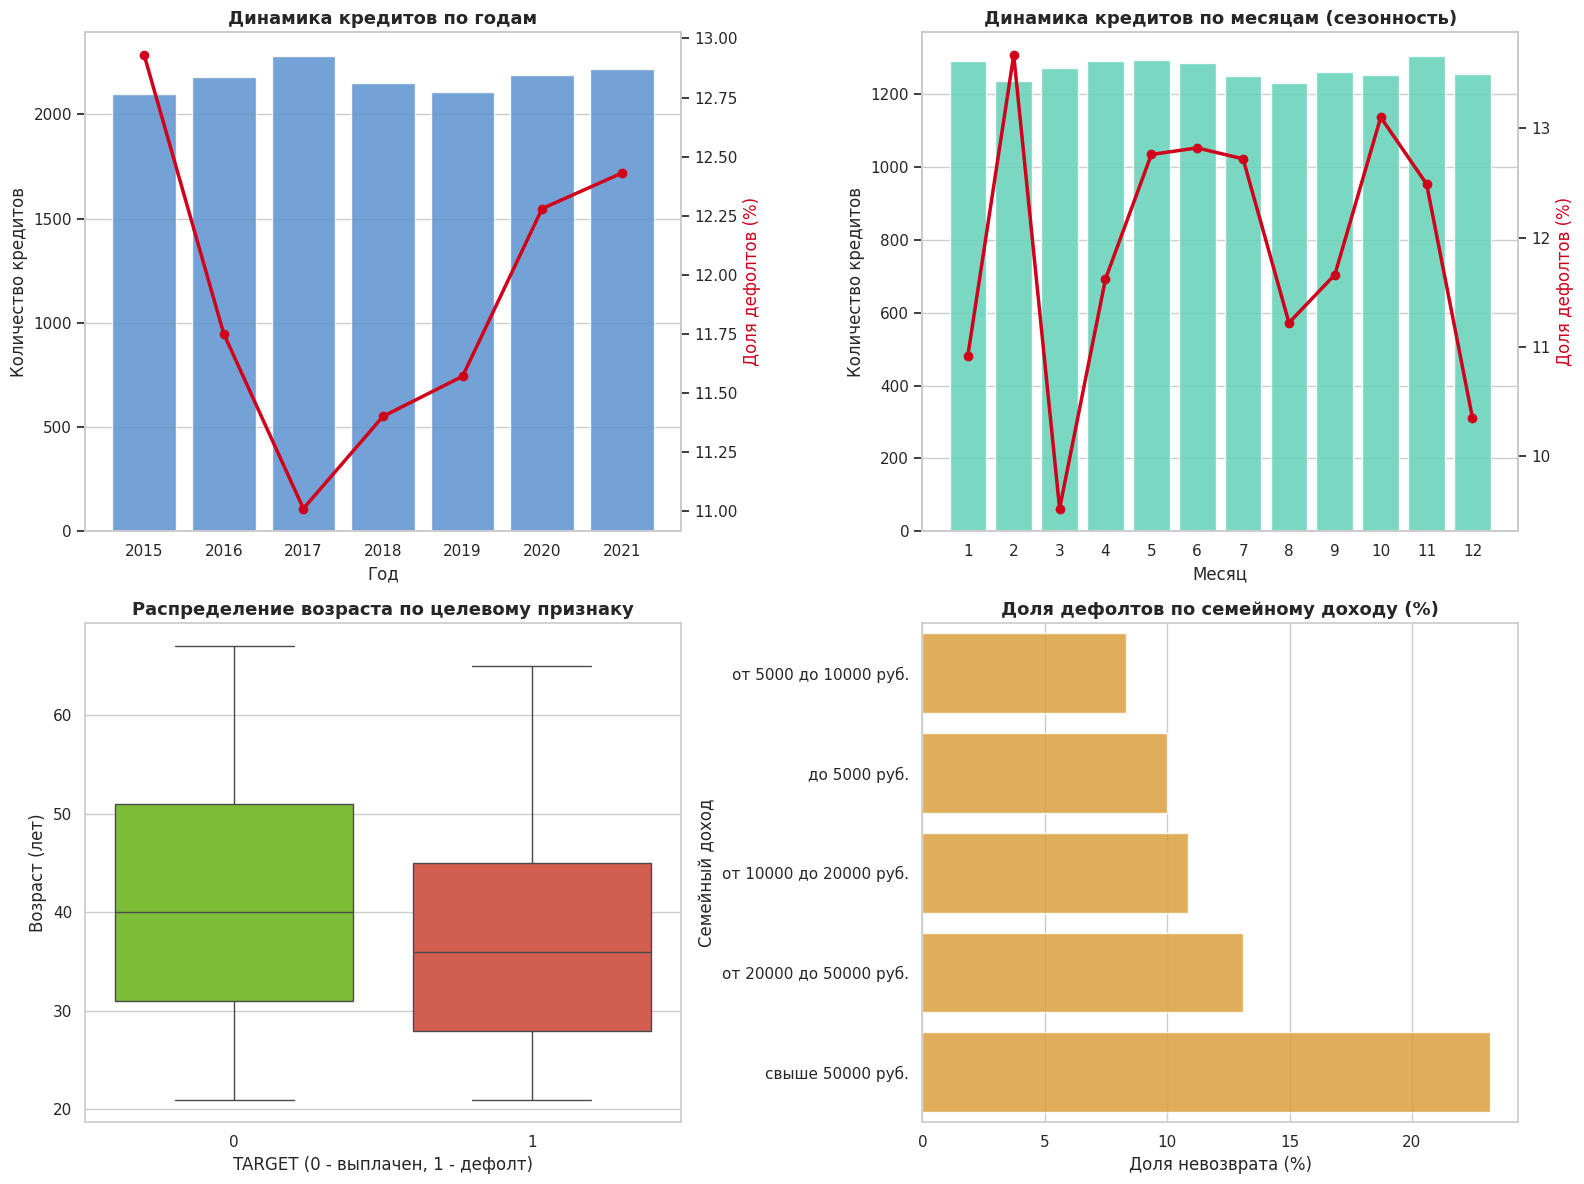

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# кредиты по годам + линия % дефолта
sns.barplot(data=yearly_stats, x='credit_year', y='Количество_кредитов', ax=axes[0, 0], color='#4A90E2', alpha=0.85)
axes[0, 0].set_title('Динамика кредитов по годам', fontsize=13, weight='bold')
axes[0, 0].set_ylabel('Количество кредитов')
axes[0, 0].set_xlabel('Год')

ax1_twin = axes[0, 0].twinx()
ax1_twin.plot(range(len(yearly_stats)), yearly_stats['Доля_дефолтов_проц'], color='#D0021B', marker='o', linewidth=2.5)
ax1_twin.set_ylabel('Доля дефолтов (%)', color='#D0021B')
ax1_twin.grid(False)

# сезонность по месяцам + линия % дефолта
sns.barplot(data=monthly_stats, x='credit_month', y='Количество_кредитов', ax=axes[0, 1], color='#50E3C2', alpha=0.85)
axes[0, 1].set_title('Динамика кредитов по месяцам (сезонность)', fontsize=13, weight='bold')
axes[0, 1].set_ylabel('Количество кредитов')
axes[0, 1].set_xlabel('Месяц')

ax2_twin = axes[0, 1].twinx()
ax2_twin.plot(range(len(monthly_stats)), monthly_stats['Доля_дефолтов_проц'], color='#D0021B', marker='o', linewidth=2.5)
ax2_twin.set_ylabel('Доля дефолтов (%)', color='#D0021B')
ax2_twin.grid(False)

# возраст клиентов по target
sns.boxplot(data=df, x='target', y='age', ax=axes[1, 0], palette=['#7ED321', '#E74C3C'], hue='target', legend=False)
axes[1, 0].set_title('Распределение возраста по целевому признаку', fontsize=13, weight='bold')
axes[1, 0].set_xlabel('TARGET (0 - выплачен, 1 - дефолт)')
axes[1, 0].set_ylabel('Возраст (лет)')

# 4. Доля дефолтов по семейному доходу
inc_df = df.groupby('family_income')['target'].mean().mul(100).reset_index().sort_values(by='target')
sns.barplot(data=inc_df, x='target', y='family_income', ax=axes[1, 1], color='#F5A623', alpha=0.85)
axes[1, 1].set_title('Доля дефолтов по семейному доходу (%)', fontsize=13, weight='bold')
axes[1, 1].set_xlabel('Доля невозврата (%)')
axes[1, 1].set_ylabel('Семейный доход')

plt.tight_layout()
plt.show()

**Итоговые выводы о влиянии признаков на целевой признак**

 Временные факторы:
   * Количество выданных кредитов устойчиво по годам (от 2 096 до 2 280 в год).
   * Доля невозврата по годам держится в границах **11.0% – 12.9%**.
   * Наблюдается выраженная сезонность: риски дефолта выше в феврале (13.67%) и октябре (13.10%), а минимальны в марте (9.52%) и декабре (10.35%).

 Числовые факторы:
   * Возраст: дефолтные клиенты в среднем моложе (37.1 лет против 40.8 лет у надежных).
   * Сумма кредита: средняя сумма займа у дефолтных заемщиков выше (15 926 руб. против 14 498 руб.).
   * История просрочек: максимальная сумма прошлой просрочки у неплательщиков почти в 2 раза превышает показатель благонадежных клиентов (413.6 руб. против 220.0 руб.).

 Социально-демографические и категориальные факторы:
   * Пенсионеры: наименее рискованная категория (дефолт всего 4.93% против 12.99% у работающих/непенсионеров).
   * Образование: клиенты с неоконченным высшим имеют наивысшую долю дефолтов (19.17%), тогда как заемщики с высшим образованием наиболее надежны (10.69%).
   * Семейный статус: повышенный риск наблюдается у клиентов в гражданском браке (16.48%) и разведенных (14.54%), наименьший — у состоящих в браке (11.25%) и вдов/вдовцов (8.84%).